# LV 3D Reconstruction — Unified ED + ES Occupancy Network (v2)

## Phase-Conditioned INR with Dice+BCE Loss, Dual-GPU Training

**Key improvements over v1:**

| Feature | v1 | **v2** |
|---|---|---|
| Data | ED-only (1,300 synthetic) | **ED + ES + Combined** (phase-conditioned) |
| Loss | BCE + consistency | **Dice + BCE + consistency + WT reg + progressive latent reg** |
| Architecture | PointNet → INR | **PointNet (phase-aware, 5-dim input)** → INR |
| Training | Single GPU, AMP | **DataParallel 2× T4, AMP, grad accumulation** |
| Augmentation | 6 transforms | **8 transforms** (+label noise, +latent interp) |
| Evaluation | Chamfer only | **Chamfer + Dice + Volume Error + WT MAE** |
| Output | Single checkpoint | **3 checkpoints + comparison CSV** |

### Pipeline
```
SAX contour points (xyz + tissue + phase)
        │
   PointNetEncoder  →  latent code z  (256-dim)
        │
   INR Decoder  ←── Fourier PE of query (x,y,z)
        │
   [endo_occ, epi_occ]  (per query point)
        │
   Marching Cubes → 3D endo/epi meshes → AHA WT
```

### Modes
- `ed_only`  — Train on ED cache only (synthetic SSM hearts)
- `es_only`  — Train on ES cache only (real ACDC/M&Ms)
- `combined` — Both caches, phase as 5th input feature (0=ED, 1=ES)

## 1. Setup

In [1]:
%pip install -q vtk scikit-image tqdm scipy nibabel scikit-learn trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 11.3 MB/s eta 0:00:00 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, time, warnings, random, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.patches import Patch
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KDTree
from skimage.measure import marching_cubes
import trimesh

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ── Hardware detection ────────────────────────────────────────
N_GPUS = torch.cuda.device_count()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  GPUs: {N_GPUS}')
for i in range(N_GPUS):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name}  ({p.total_memory / 1e9:.1f} GB)')

# Enable cuDNN benchmarking for T4 tensor cores
if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

Device: cuda  |  GPUs: 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)


## 2. Configuration

**Three training modes:**
- `ed_only` — Uses the ED occupancy cache (1,300 synthetic hearts from SSM)
- `es_only` — Uses the ES occupancy cache (real ACDC/M&Ms segmentations)
- `combined` — Both caches merged, with a `phase` feature (0=ED, 1=ES) appended to each contour point

The ES cache has a different format (`pts`/`occ` instead of `contour`/`query`/`endo_occ`/`epi_occ`).
The dataset class handles both transparently.

In [3]:

# ══════════════════════════════════════════════════════════════
# Training Mode: "ed_only" | "es_only" | "combined"
# ══════════════════════════════════════════════════════════════
MODE = 'es_only'   # ← CHANGE THIS to run each experiment

CFG = dict(
    # ── Mode ──────────────────────────────────────────────────
    mode           = MODE,

    # ── Cache paths (Kaggle dataset inputs) ───────────────────
    ed_cache_dir   = '/kaggle/input/datasets/andrefce/cached-dataset/occupancy_cache',
    es_cache_dir   = '/kaggle/input/datasets/andrefce/es-data/es_occupancy_cache',
    output_dir     = '/kaggle/working',

    # ── Architecture ──────────────────────────────────────────
    input_dim      = 5 if MODE == 'combined' else 4,   # xyz+tissue (+phase)
    latent_dim     = 256,
    fourier_L      = 6,
    decoder_hidden = 512,
    decoder_layers = 8,
    skip_layer     = 4,

    # ── Training ──────────────────────────────────────────────
    epochs         = 500,
    batch_size     = 16,                      # per-GPU; effective = 16 × N_GPU
    lr             = 1e-4,
    weight_decay   = 5e-4,
    patience       = 80,
    dl_workers     = 4,
    grad_accum     = 1,                       # increase if OOM
    grad_clip      = 1.0,

    # ── Loss weights ──────────────────────────────────────────
    dice_weight       = 1.0,
    bce_weight        = 1.0,
    consistency_w     = 0.5,
    wall_reg_w        = 0.1,
    latent_reg_max    = 1e-4,                 # progressive warm-up over 100 epochs
    latent_reg_warmup = 100,

    # ── Inference ─────────────────────────────────────────────
    grid_res       = 64,
    iso_thresh     = 0.5,

    # ── Augmentation (training only) ──────────────────────────
    aug_translate_xy_std = 0.18,
    aug_jitter_std       = 0.06,
    aug_slice_drop_prob  = 0.25,
    aug_rotate_prob      = 0.5,
    aug_rotate_max_deg   = 15.0,
    aug_scale_std        = 0.03,
    aug_contour_drop     = 0.30,
    aug_label_noise_prob = 0.02,              # NEW: flip 2% of tissue labels

    seed           = 42,
)

# ── Validate paths ────────────────────────────────────────────
for key in ['ed_cache_dir', 'es_cache_dir']:
    path = CFG[key]
    if path and os.path.isdir(path):
        n = len(list(Path(path).glob('sample_*.npz')))
        print(f'  ✅ {key}: {path}  ({n} samples)')
    else:
        print(f'  ⚠  {key}: {path}  (not found)')
        CFG[key] = None

os.makedirs(CFG['output_dir'], exist_ok=True)
print(f'\n  Mode        : {CFG["mode"]}')
print(f'  Input dim   : {CFG["input_dim"]}')
print(f'  Batch size  : {CFG["batch_size"]} × {max(1, N_GPUS)} GPUs = {CFG["batch_size"] * max(1, N_GPUS)} effective')
print(f'  Epochs      : {CFG["epochs"]}')
print(f'  Loss        : Dice({CFG["dice_weight"]}) + BCE({CFG["bce_weight"]}) + Consist({CFG["consistency_w"]}) + WallReg({CFG["wall_reg_w"]})')
print(f'  Latent reg  : warm {CFG["latent_reg_warmup"]} epochs → λ={CFG["latent_reg_max"]}')


  ✅ ed_cache_dir: /kaggle/input/datasets/andrefce/cached-dataset/occupancy_cache  (1300 samples)
  ✅ es_cache_dir: /kaggle/input/datasets/andrefce/es-data/es_occupancy_cache  (460 samples)

  Mode        : es_only
  Input dim   : 4
  Batch size  : 16 × 2 GPUs = 32 effective
  Epochs      : 500
  Loss        : Dice(1.0) + BCE(1.0) + Consist(0.5) + WallReg(0.1)
  Latent reg  : warm 100 epochs → λ=0.0001


## 3. Dataset & Augmentation

Handles **two different cache formats** transparently:
- **ED cache** (from `build-lv-cache`): `contour (N,4)`, `query (2048,3)`, `endo_occ`, `epi_occ`, `scale`, `centroid`
- **ES cache** (from `ES_dataset`): `pts (Q,3)`, `occ (Q,)`, `endo_verts`, `epi_verts`, `faces`, `coeffs`, `phase`

For ES samples that lack the ED-style fields, we reconstruct them from the available data.

In [4]:

# ══════════════════════════════════════════════════════════════
# Augmentation — 8 scientifically-motivated transforms
# ══════════════════════════════════════════════════════════════

def augment_contour(contour, cfg, rng):
    """Apply realistic SAX acquisition augmentations to encoder input ONLY.

    The ground-truth occupancy (query/endo_occ/epi_occ) is NOT touched.

    Augmentations (8 total):
    1. Per-slice XY translation  — breath-hold misregistration (shared endo+epi)
    2. Per-point XY jitter       — segmentation noise
    3. Random slice dropout      — missing/corrupted slices
    4. Z-axis rotation           — patient orientation
    5. Global scale jitter       — breathing variation
    6. Contour point dropout     — incomplete segmentation
    7. Label noise               — NEW: flip 2% of tissue labels (0↔1)
    8. Phase preserved           — phase column never augmented
    """
    contour = contour.copy()
    n_feat = contour.shape[1]  # 4 (no phase) or 5 (with phase)
    xyz = contour[:, :3]

    # Identify unique slices by z
    z_rounded = np.round(xyz[:, 2], decimals=5)
    unique_z  = np.unique(z_rounded)

    # 1. Per-slice XY translation (shared by endo + epi at same z)
    slice_shifts = {
        float(z): rng.normal(0, cfg['aug_translate_xy_std'], 2).astype(np.float32)
        for z in unique_z
    }
    for z in unique_z:
        mask = z_rounded == z
        shift = slice_shifts[float(z)]
        xyz[mask, 0] += shift[0]
        xyz[mask, 1] += shift[1]

    # 2. Per-point XY jitter
    noise = rng.normal(0, cfg['aug_jitter_std'], xyz[:, :2].shape).astype(np.float32)
    xyz[:, :2] += noise

    # 3. Random slice dropout (keep ≥3 slices)
    if len(unique_z) > 3 and rng.random() < cfg['aug_slice_drop_prob']:
        n_drop   = rng.integers(1, max(2, len(unique_z) // 3))
        drop_idx = rng.choice(len(unique_z), n_drop, replace=False)
        drop_set = set(unique_z[drop_idx])
        keep     = np.array([z not in drop_set for z in z_rounded])
        if keep.sum() >= 6:
            contour = contour[keep]
            xyz = contour[:, :3]

    # 4. Rotation around LV long axis (z-axis)
    if rng.random() < cfg.get('aug_rotate_prob', 0.5):
        max_deg = cfg.get('aug_rotate_max_deg', 15.0)
        angle   = rng.uniform(-max_deg, max_deg) * np.pi / 180.0
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        cx, cy = xyz[:, 0].mean(), xyz[:, 1].mean()
        dx, dy = xyz[:, 0] - cx, xyz[:, 1] - cy
        xyz[:, 0] = cx + cos_a * dx - sin_a * dy
        xyz[:, 1] = cy + sin_a * dx + cos_a * dy

    # 5. Global scale jitter
    scale_factor = 1.0 + rng.normal(0, cfg.get('aug_scale_std', 0.03))
    scale_factor = np.clip(scale_factor, 0.85, 1.15)
    xyz *= scale_factor

    # 6. Contour point dropout
    drop_frac = cfg.get('aug_contour_drop', 0.30)
    if drop_frac > 0 and len(contour) > 20:
        keep_mask = rng.random(len(contour)) > drop_frac
        if keep_mask.sum() >= 10:
            contour = contour[keep_mask]

    # 7. Label noise — flip 2% of tissue labels (column 3)
    lnp = cfg.get('aug_label_noise_prob', 0.02)
    if lnp > 0:
        flip = rng.random(len(contour)) < lnp
        contour[flip, 3] = 1.0 - contour[flip, 3]

    # 8. Phase column (index 4) is NEVER augmented

    return contour


print('✅ Augmentation function defined (8 transforms)')


# ══════════════════════════════════════════════════════════════
# ES cache adapter — convert ES format to ED-compatible format
# ──────────────────────────────────────────────────────────────
# The ES cache (built by ES_dataset.ipynb) stores per sample:
#   pts        (Q,3)  — query points in WORLD (mm) space
#   occ        (Q,)   — myocardial-wall mask
#                       (cache builder defines: outside_endo & inside_epi
#                        under outward-normal assumption)
#   endo_verts (V,3)  — SSM mesh, world space
#   epi_verts  (V,3)  — endo offset along vertex normals
#   faces      (F,3)  — shared SSM topology
#
# Two known data hazards make a naïve adapter fail badly:
#
# (1) SWAPPED LABELS.  generate_epi(endo, faces) does
#       epi = endo + normals * offset
#     If the SSM template winding is INWARD on a given sample,
#     `normals` point inward and the "epi" mesh ends up SMALLER
#     than the "endo" mesh — i.e. the labels in the .npz are
#     anatomically reversed.  We see this as endo_occ ≫ epi_occ
#     after a sign test (e.g. 73% / 95% with wall=21%).
#
# (2) FLIPPED NORMALS PER MESH.  Even after fixing (1), the sign
#     of (P − v_nearest) · n_v can correspond to either inside or
#     outside depending on winding.  We disambiguate per-mesh
#     using both a SIZE prior (cavity is the smaller region) and
#     the saved wall mask as oracle.
#
# Strategy
# --------
#   a. Auto-swap endo/epi labels by mean radius (smaller = endo).
#   b. KD-tree + sign test, then per-mesh polarity selection:
#        endo  → choose polarity that minimises  (size + 5·wall_overlap_frac)
#        epi   → choose polarity that maximises  saved-wall containment
#   c. Enforce anatomy:  inside_epi |= inside_endo,
#                        inside_endo &= ~saved_wall_mask
#   d. Sanity check: if  |inside_epi - inside_endo|  disagrees a lot
#      with the saved wall, log a warning so we know.
# ══════════════════════════════════════════════════════════════
from scipy.spatial import cKDTree as _cKDTree


def _vertex_normals_plain(verts, faces):
    """Area-weighted per-vertex normals — NO auto-orient.

    Identical to ES_dataset.ipynb::compute_vertex_normals so the
    adapter sees the exact same orientation as the cache builder.
    """
    v0 = verts[faces[:, 0]]; v1 = verts[faces[:, 1]]; v2 = verts[faces[:, 2]]
    fn = np.cross(v1 - v0, v2 - v0)              # area-weighted face normals
    vn = np.zeros_like(verts)
    for i in range(3):
        np.add.at(vn, faces[:, i], fn)
    n = np.linalg.norm(vn, axis=1, keepdims=True)
    return vn / (n + 1e-8)


def _slice_mesh_at_z(verts, faces, z, pts_per_ring=60):
    """Intersect triangle mesh with plane z=const → sorted ring points."""
    crossings = []
    for ia, ib in [(0,1),(1,2),(2,0)]:
        za = verts[faces[:, ia], 2]
        zb = verts[faces[:, ib], 2]
        mask = (za - z) * (zb - z) < 0
        if mask.sum() == 0:
            continue
        t  = (z - za[mask]) / (zb[mask] - za[mask])
        pa = verts[faces[mask, ia], :2]
        pb = verts[faces[mask, ib], :2]
        crossings.append(pa + t[:, None] * (pb - pa))
    if not crossings:
        return None
    pts = np.vstack(crossings)
    if len(pts) < 3:
        return None
    c     = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:,1]-c[1], pts[:,0]-c[0]))
    pts   = pts[order]
    if len(pts) > pts_per_ring:
        idx = np.round(np.linspace(0, len(pts)-1, pts_per_ring)).astype(int)
        pts = pts[idx]
    return pts.astype(np.float32)


def _normalize_xyz(xyz, centroid=None, scale=None):
    """Centroid + mean-radius normalisation matching build-lv-cache."""
    out = xyz.copy().astype(np.float32)
    if centroid is None:
        cxy      = out[:, :2].mean(0)
        centroid = np.array([cxy[0], cxy[1], out[:, 2].mean()], dtype=np.float32)
    if scale is None:
        scale = float(np.linalg.norm(out[:, :2] - centroid[:2], axis=1)
                                .mean().clip(min=1e-3))
    out -= centroid
    out /= scale
    return out, centroid, float(scale)


def _pick_endo_polarity(sign_vals, saved_wall):
    """Cavity = SMALLER region disjoint from the wall.

    score = (region size fraction) + 5 · (wall overlap fraction within region)
    Lower score → more cavity-like.
    """
    cand_a = sign_vals < 0
    cand_b = ~cand_a
    sa, sb = cand_a.sum(), cand_b.sum()
    if sa == 0: return cand_b
    if sb == 0: return cand_a
    n   = len(sign_vals)
    ova = (cand_a & saved_wall).sum() / sa if saved_wall is not None else 0.0
    ovb = (cand_b & saved_wall).sum() / sb if saved_wall is not None else 0.0
    score_a = sa / n + 5.0 * ova
    score_b = sb / n + 5.0 * ovb
    return cand_a if score_a < score_b else cand_b


def _pick_epi_polarity(sign_vals, saved_wall):
    """Outer surface interior = region that CONTAINS the wall.

    Without a wall oracle we fall back to the larger region.
    """
    cand_a = sign_vals < 0
    cand_b = ~cand_a
    if saved_wall is not None and saved_wall.sum() > 20:
        cont_a = (cand_a & saved_wall).sum() / saved_wall.sum()
        cont_b = (cand_b & saved_wall).sum() / saved_wall.sum()
        return cand_a if cont_a > cont_b else cand_b
    return cand_a if cand_a.sum() > cand_b.sum() else cand_b


# Counters so we can see how often each correction fires
adapt_es_sample_stats = {'swapped': 0, 'total': 0, 'wall_disagree': 0}


def adapt_es_sample(d, n_slices=10, pts_per_ring=40, n_query=2048, rng=None):
    """Convert an ES-format .npz dict into the ED-compatible format.

    See block comment above for the data-hazard analysis.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    endo_v = d['endo_verts'].astype(np.float64)
    epi_v  = d['epi_verts'].astype(np.float64)
    faces  = d['faces'].astype(np.int64)

    # ── (1) Auto-swap labels if cache is reversed ────────────
    # True endo (cavity boundary) has SMALLER mean radius from the
    # mesh centroid than true epi.  When generate_epi() pushed
    # vertices inward (inverted SSM winding) the labels are flipped.
    swapped = False
    if endo_v.mean(0) is not None:
        cm = 0.5 * (endo_v.mean(0) + epi_v.mean(0))
        r_endo = np.linalg.norm(endo_v - cm, axis=1).mean()
        r_epi  = np.linalg.norm(epi_v  - cm, axis=1).mean()
        if r_endo > r_epi * 1.02:        # 2% margin to avoid noise flips
            endo_v, epi_v = epi_v, endo_v
            swapped = True
            adapt_es_sample_stats['swapped'] += 1
    adapt_es_sample_stats['total'] += 1

    # ── Sign-test infrastructure (computed in WORLD space) ───
    n_endo = _vertex_normals_plain(endo_v, faces)
    n_epi  = _vertex_normals_plain(epi_v,  faces)
    tree_endo = _cKDTree(endo_v)
    tree_epi  = _cKDTree(epi_v)

    # ── Build query set (prefer saved pts) ───────────────────
    pts_world = d['pts'].astype(np.float32) if 'pts' in d.files else None
    occ_wall  = (d['occ'].astype(np.float32) > 0.5) if 'occ' in d.files else None

    if pts_world is not None and len(pts_world) >= n_query:
        sel = rng.choice(len(pts_world), n_query, replace=False)
        q_world = pts_world[sel]
        wall_q  = occ_wall[sel] if occ_wall is not None else None
    elif pts_world is not None:
        n_extra = n_query - len(pts_world)
        all_v   = np.vstack([endo_v, epi_v])
        lo, hi  = all_v.min(0) - 5.0, all_v.max(0) + 5.0
        r_pts   = rng.uniform(lo, hi, (n_extra, 3)).astype(np.float32)
        q_world = np.vstack([pts_world, r_pts]).astype(np.float32)
        wall_q  = (np.concatenate([occ_wall, np.zeros(n_extra, bool)])
                   if occ_wall is not None else None)
    else:
        all_v   = np.vstack([endo_v, epi_v])
        s_std   = 2.0
        n_surf  = int(n_query * 0.4)
        n_rand  = n_query - 2 * n_surf
        e_pts   = (endo_v[rng.integers(0, len(endo_v), n_surf)]
                   + rng.normal(0, s_std, (n_surf, 3)).astype(np.float32))
        p_pts   = (epi_v[rng.integers(0, len(epi_v),  n_surf)]
                   + rng.normal(0, s_std, (n_surf, 3)).astype(np.float32))
        lo, hi  = all_v.min(0) - 5.0, all_v.max(0) + 5.0
        r_pts   = rng.uniform(lo, hi, (n_rand, 3)).astype(np.float32)
        q_world = np.vstack([e_pts, p_pts, r_pts]).astype(np.float32)
        wall_q  = None

    # ── Signed-distance via KDTree + vertex normals ──────────
    _, ie = tree_endo.query(q_world)
    _, ip = tree_epi.query(q_world)
    sign_endo = np.einsum('ij,ij->i', q_world - endo_v[ie], n_endo[ie])
    sign_epi  = np.einsum('ij,ij->i', q_world - epi_v[ip],  n_epi[ip])

    # ── (2) Per-mesh polarity disambiguation ─────────────────
    inside_endo = _pick_endo_polarity(sign_endo, wall_q)
    inside_epi  = _pick_epi_polarity (sign_epi,  wall_q)

    # ── (3) Anatomical enforcement ───────────────────────────
    if wall_q is not None:
        # The cache's wall mask is the highest-confidence label we have.
        # Cavity must be DISJOINT from wall.
        inside_endo = inside_endo & ~wall_q
    inside_epi = inside_epi | inside_endo
    if wall_q is not None:
        inside_epi = inside_epi | wall_q     # outer must contain wall

    endo_occ = inside_endo.astype(np.float32)
    epi_occ  = inside_epi.astype(np.float32)

    # ── (4) Sanity check vs saved wall ───────────────────────
    if wall_q is not None and wall_q.sum() > 20:
        derived_wall = (inside_epi & ~inside_endo)
        agree = (derived_wall == wall_q).mean()
        if agree < 0.85:
            adapt_es_sample_stats['wall_disagree'] += 1

    # ── Normalise everything from endo centroid ──────────────
    _, centroid, scale = _normalize_xyz(endo_v.astype(np.float32))
    endo_vn, _, _ = _normalize_xyz(endo_v.astype(np.float32), centroid, scale)
    epi_vn,  _, _ = _normalize_xyz(epi_v.astype(np.float32),  centroid, scale)
    q_n           = ((q_world - centroid) / scale).astype(np.float32)

    # ── Synthesise SAX contours from normalised meshes ───────
    all_vn = np.vstack([endo_vn, epi_vn])
    z_min, z_max = all_vn[:, 2].min(), all_vn[:, 2].max()
    margin = (z_max - z_min) * 0.05
    z_ctrs = np.linspace(z_min + margin, z_max - margin, n_slices).astype(np.float32)

    all_xyz, all_tissue = [], []
    for zc in z_ctrs:
        for label, vv in [(0.0, endo_vn), (1.0, epi_vn)]:
            ring = _slice_mesh_at_z(vv, faces, float(zc), pts_per_ring)
            if ring is not None:
                z_col = np.full(len(ring), zc, dtype=np.float32)
                all_xyz.append(np.column_stack([ring, z_col]))
                all_tissue.append(np.full(len(ring), label, dtype=np.float32))

    if not all_xyz:
        return None

    contour = np.column_stack([
        np.vstack(all_xyz).astype(np.float32),
        np.concatenate(all_tissue),
    ]).astype(np.float32)

    # ── One-shot diagnostic print ────────────────────────────
    if not getattr(adapt_es_sample, '_dbg_printed', False):
        e_frac = float(endo_occ.mean())
        p_frac = float(epi_occ.mean())
        wall_f = float((epi_occ - endo_occ).clip(0).mean())
        n_pts  = int(d['pts'].shape[0]) if 'pts' in d.files else 0
        print(f'  [adapt_es_sample] sample 0 → endo_occ={e_frac:.2%}, '
              f'epi_occ={p_frac:.2%}, wall={wall_f:.2%}  '
              f'(saved pts={n_pts}, swapped={swapped})')
        adapt_es_sample._dbg_printed = True

    return dict(
        contour    = contour,
        query      = q_n,
        endo_occ   = endo_occ,
        epi_occ    = epi_occ,
        scale      = np.float32(scale),
        centroid   = centroid.astype(np.float32),
        endo_verts = endo_vn.astype(np.float32),    # for viz / GT comparison
        epi_verts  = epi_vn.astype(np.float32),
        faces      = faces.astype(np.int32),
    )


print('✅ ES adapter function defined (auto-swap + size-prior + wall oracle)')


# ══════════════════════════════════════════════════════════════
# Unified Dataset — with pre-caching of ES adapter results
# ══════════════════════════════════════════════════════════════

class LVOccDataset(Dataset):
    """Unified dataset that handles both ED and ES cache formats.

    ES samples are pre-adapted at __init__ time so that __getitem__
    is fast and doesn't bottleneck the GPU pipeline.

    For 'combined' mode, appends a phase feature (0=ED, 1=ES) as
    the 5th column of the contour tensor.
    """

    def __init__(self, file_list, phase_labels=None, augment=False, cfg=None):
        self.files   = file_list
        self.phases  = phase_labels
        self.augment = augment
        self.cfg     = cfg or CFG

        # ── Pre-cache ES adapter results ──────────────────────
        self._es_cache = {}
        n_es = 0
        # Reset per-dataset so we get one diagnostic print and fresh stats
        if hasattr(adapt_es_sample, '_dbg_printed'):
            del adapt_es_sample._dbg_printed
        before = adapt_es_sample_stats.copy()

        for i, fp in enumerate(tqdm(file_list, desc='Pre-caching ES samples', leave=False)):
            d = np.load(fp, allow_pickle=True)
            if 'contour' not in d.files and 'endo_verts' in d.files:
                adapted = adapt_es_sample(d, rng=np.random.default_rng(42 + i))
                if adapted is not None:
                    self._es_cache[i] = adapted
                    n_es += 1
        if n_es > 0:
            sw = adapt_es_sample_stats['swapped']      - before['swapped']
            wd = adapt_es_sample_stats['wall_disagree'] - before['wall_disagree']
            print(f'  Pre-cached {n_es} ES samples  '
                  f'(label-swapped: {sw}, wall-disagree>15%: {wd})')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        # ── Use pre-cached ES result if available ─────────────
        if i in self._es_cache:
            adapted  = self._es_cache[i]
            contour  = adapted['contour'].copy()
            query    = adapted['query'].copy()
            endo_occ = adapted['endo_occ'].copy()
            epi_occ  = adapted['epi_occ'].copy()
            scale    = adapted['scale']
            centroid = adapted['centroid'].copy()
        else:
            d = np.load(self.files[i], allow_pickle=True)

            if 'contour' in d.files and 'query' in d.files:
                # ED-format cache: ready to use
                contour  = d['contour'].astype(np.float32)
                query    = d['query'].astype(np.float32)
                endo_occ = d['endo_occ'].astype(np.float32)
                epi_occ  = d['epi_occ'].astype(np.float32)
                scale    = np.float32(d['scale'])
                centroid = d['centroid'].astype(np.float32)
            elif 'endo_verts' in d.files and 'epi_verts' in d.files:
                # ES-format cache: adapt (fallback for uncached)
                adapted = adapt_es_sample(d, rng=np.random.default_rng())
                if adapted is None:
                    return self.__getitem__((i + 1) % len(self))
                contour  = adapted['contour']
                query    = adapted['query']
                endo_occ = adapted['endo_occ']
                epi_occ  = adapted['epi_occ']
                scale    = adapted['scale']
                centroid = adapted['centroid']
            else:
                raise ValueError(f'Unknown cache format: {list(d.keys())}')

        # ── Append phase feature for combined mode ────────────
        if self.phases is not None:
            phase_val = self.phases[i]
            phase_col = np.full((len(contour), 1), phase_val, dtype=np.float32)
            contour = np.column_stack([contour, phase_col])

        # ── Augmentation (training only) ──────────────────────
        if self.augment:
            rng     = np.random.default_rng()
            contour = augment_contour(contour, self.cfg, rng)

        return {
            'contour':      contour,
            'contour_mask': np.ones(len(contour), dtype=bool),
            'query':        query,
            'endo_occ':     endo_occ,
            'epi_occ':      epi_occ,
            'scale':        scale,
            'centroid':     centroid,
        }


def collate_lv(batch):
    """Pad variable-length contours and queries to batch max."""
    B     = len(batch)
    feat  = batch[0]['contour'].shape[1]  # 4 or 5
    n_max = max(x['contour'].shape[0] for x in batch)
    q_max = max(x['query'].shape[0]   for x in batch)

    contour  = np.zeros((B, n_max, feat), dtype=np.float32)
    c_mask   = np.zeros((B, n_max),       dtype=bool)
    query    = np.zeros((B, q_max, 3),    dtype=np.float32)
    endo     = np.zeros((B, q_max),       dtype=np.float32)
    epi      = np.zeros((B, q_max),       dtype=np.float32)
    scale    = np.zeros((B,),             dtype=np.float32)
    centroid = np.zeros((B, 3),           dtype=np.float32)

    for b, x in enumerate(batch):
        n, q = x['contour'].shape[0], x['query'].shape[0]
        contour[b, :n]  = x['contour'];  c_mask[b, :n] = True
        query[b, :q]    = x['query']
        endo[b, :q]     = x['endo_occ'];  epi[b, :q] = x['epi_occ']
        scale[b]        = x['scale'];     centroid[b] = x['centroid']

    return {
        'contour':      torch.from_numpy(contour),
        'contour_mask': torch.from_numpy(c_mask),
        'query':        torch.from_numpy(query),
        'endo_occ':     torch.from_numpy(endo),
        'epi_occ':      torch.from_numpy(epi),
        'scale':        torch.from_numpy(scale),
        'centroid':     torch.from_numpy(centroid),
    }


# ── Build file lists and splits ──────────────────────────────

def build_dataset_files(cfg):
    """Collect .npz files and splits for the chosen mode."""
    files, phases = [], []

    if cfg['mode'] in ('ed_only', 'combined') and cfg['ed_cache_dir']:
        ed_dir = Path(cfg['ed_cache_dir'])
        with open(ed_dir / 'split.json') as f:
            ed_split = json.load(f)
        for idx in ed_split['tr'] + ed_split['val'] + ed_split['te']:
            fp = ed_dir / f'sample_{int(idx):04d}.npz'
            if fp.exists():
                files.append(str(fp))
                phases.append(0.0)

    if cfg['mode'] in ('es_only', 'combined') and cfg['es_cache_dir']:
        es_dir = Path(cfg['es_cache_dir'])
        if (es_dir / 'split.json').exists():
            with open(es_dir / 'split.json') as f:
                es_split = json.load(f)
            for idx in es_split['tr'] + es_split['val'] + es_split['te']:
                fp = es_dir / f'sample_{int(idx):04d}.npz'
                if fp.exists():
                    files.append(str(fp))
                    phases.append(1.0)
        else:
            for fp in sorted(es_dir.glob('sample_*.npz')):
                files.append(str(fp))
                phases.append(1.0)

    if not files:
        raise FileNotFoundError('No cache files found! Check cache_dir paths.')

    # Phase labels only used in 'combined' mode
    phase_labels = phases if cfg['mode'] == 'combined' else None

    # Split: 80/10/10
    indices = np.arange(len(files))
    np.random.seed(cfg['seed'])
    np.random.shuffle(indices)
    n_tr  = int(0.80 * len(indices))
    n_val = int(0.10 * len(indices))
    tr_idx  = indices[:n_tr]
    val_idx = indices[n_tr:n_tr+n_val]
    te_idx  = indices[n_tr+n_val:]

    return files, phase_labels, tr_idx, val_idx, te_idx


files, phase_labels, tr_idx, val_idx, te_idx = build_dataset_files(CFG)

print(f'Total samples: {len(files)}')
if phase_labels:
    n_ed = sum(1 for p in phase_labels if p == 0.0)
    n_es = sum(1 for p in phase_labels if p == 1.0)
    print(f'  ED: {n_ed}  |  ES: {n_es}')
print(f'Train: {len(tr_idx)}  |  Val: {len(val_idx)}  |  Test: {len(te_idx)}')

# ── DataLoaders ───────────────────────────────────────────────
def _subset(files, phases, idxs):
    f = [files[i] for i in idxs]
    p = [phases[i] for i in idxs] if phases else None
    return f, p

tr_files,  tr_phases  = _subset(files, phase_labels, tr_idx)
val_files, val_phases = _subset(files, phase_labels, val_idx)
te_files,  te_phases  = _subset(files, phase_labels, te_idx)

PIN = (DEVICE.type == 'cuda')
EFF_BS = CFG['batch_size'] * max(1, N_GPUS)   # per-GPU batch × num GPUs
USE_PERSISTENT = (CFG['dl_workers'] > 0)

print(f'\nBuilding datasets (pre-caching ES samples)...')
tr_ds  = LVOccDataset(tr_files,  tr_phases,  augment=True,  cfg=CFG)
val_ds = LVOccDataset(val_files, val_phases, augment=False, cfg=CFG)
te_ds  = LVOccDataset(te_files,  te_phases,  augment=False, cfg=CFG)

tr_loader  = DataLoader(
    tr_ds, batch_size=EFF_BS, shuffle=True,
    num_workers=CFG['dl_workers'], pin_memory=PIN,
    persistent_workers=USE_PERSISTENT, prefetch_factor=2,
    collate_fn=collate_lv)
val_loader = DataLoader(
    val_ds, batch_size=EFF_BS, shuffle=False,
    num_workers=CFG['dl_workers'], pin_memory=PIN,
    persistent_workers=USE_PERSISTENT, prefetch_factor=2,
    collate_fn=collate_lv)
te_loader  = DataLoader(
    te_ds, batch_size=EFF_BS, shuffle=False,
    num_workers=CFG['dl_workers'], pin_memory=PIN,
    persistent_workers=USE_PERSISTENT, prefetch_factor=2,
    collate_fn=collate_lv)

print(f'\n✅ DataLoaders ready')
print(f'  Effective batch size : {EFF_BS}')
print(f'  Workers              : {CFG["dl_workers"]} (persistent={USE_PERSISTENT})')
print(f'  Train batches: {len(tr_loader)}  |  Val: {len(val_loader)}  |  Test: {len(te_loader)}')


✅ Augmentation function defined (8 transforms)
✅ ES adapter function defined (auto-swap + size-prior + wall oracle)
Total samples: 460
Train: 368  |  Val: 46  |  Test: 46

Building datasets (pre-caching ES samples)...


Pre-caching ES samples:   0%|          | 0/368 [00:00<?, ?it/s]

  [adapt_es_sample] sample 0 → endo_occ=48.34%, epi_occ=69.82%, wall=21.48%  (saved pts=2560, swapped=True)
  Pre-cached 368 ES samples  (label-swapped: 368, wall-disagree>15%: 0)


Pre-caching ES samples:   0%|          | 0/46 [00:00<?, ?it/s]

  [adapt_es_sample] sample 0 → endo_occ=48.93%, epi_occ=74.90%, wall=25.98%  (saved pts=2560, swapped=True)
  Pre-cached 46 ES samples  (label-swapped: 46, wall-disagree>15%: 0)


Pre-caching ES samples:   0%|          | 0/46 [00:00<?, ?it/s]

  [adapt_es_sample] sample 0 → endo_occ=47.75%, epi_occ=71.88%, wall=24.12%  (saved pts=2560, swapped=True)
  Pre-cached 46 ES samples  (label-swapped: 46, wall-disagree>15%: 0)

✅ DataLoaders ready
  Effective batch size : 32
  Workers              : 4 (persistent=True)
  Train batches: 12  |  Val: 2  |  Test: 2


## 3.5 Sanity Check — Inspect Training Data

Before training, visualise a few samples from the **training set** to confirm:

1. **SAX contour slices** show two clearly-separated rings per slice (endo inside, epi outside).
2. **GT mesh pair** (endo smaller, epi larger, both anatomically reasonable).
3. **Occupancy stats**: endo fraction < epi fraction, wall = epi − endo > 0.

If endo/epi look **identical or swapped**, the ES adapter is mis-labelling — training will fail.


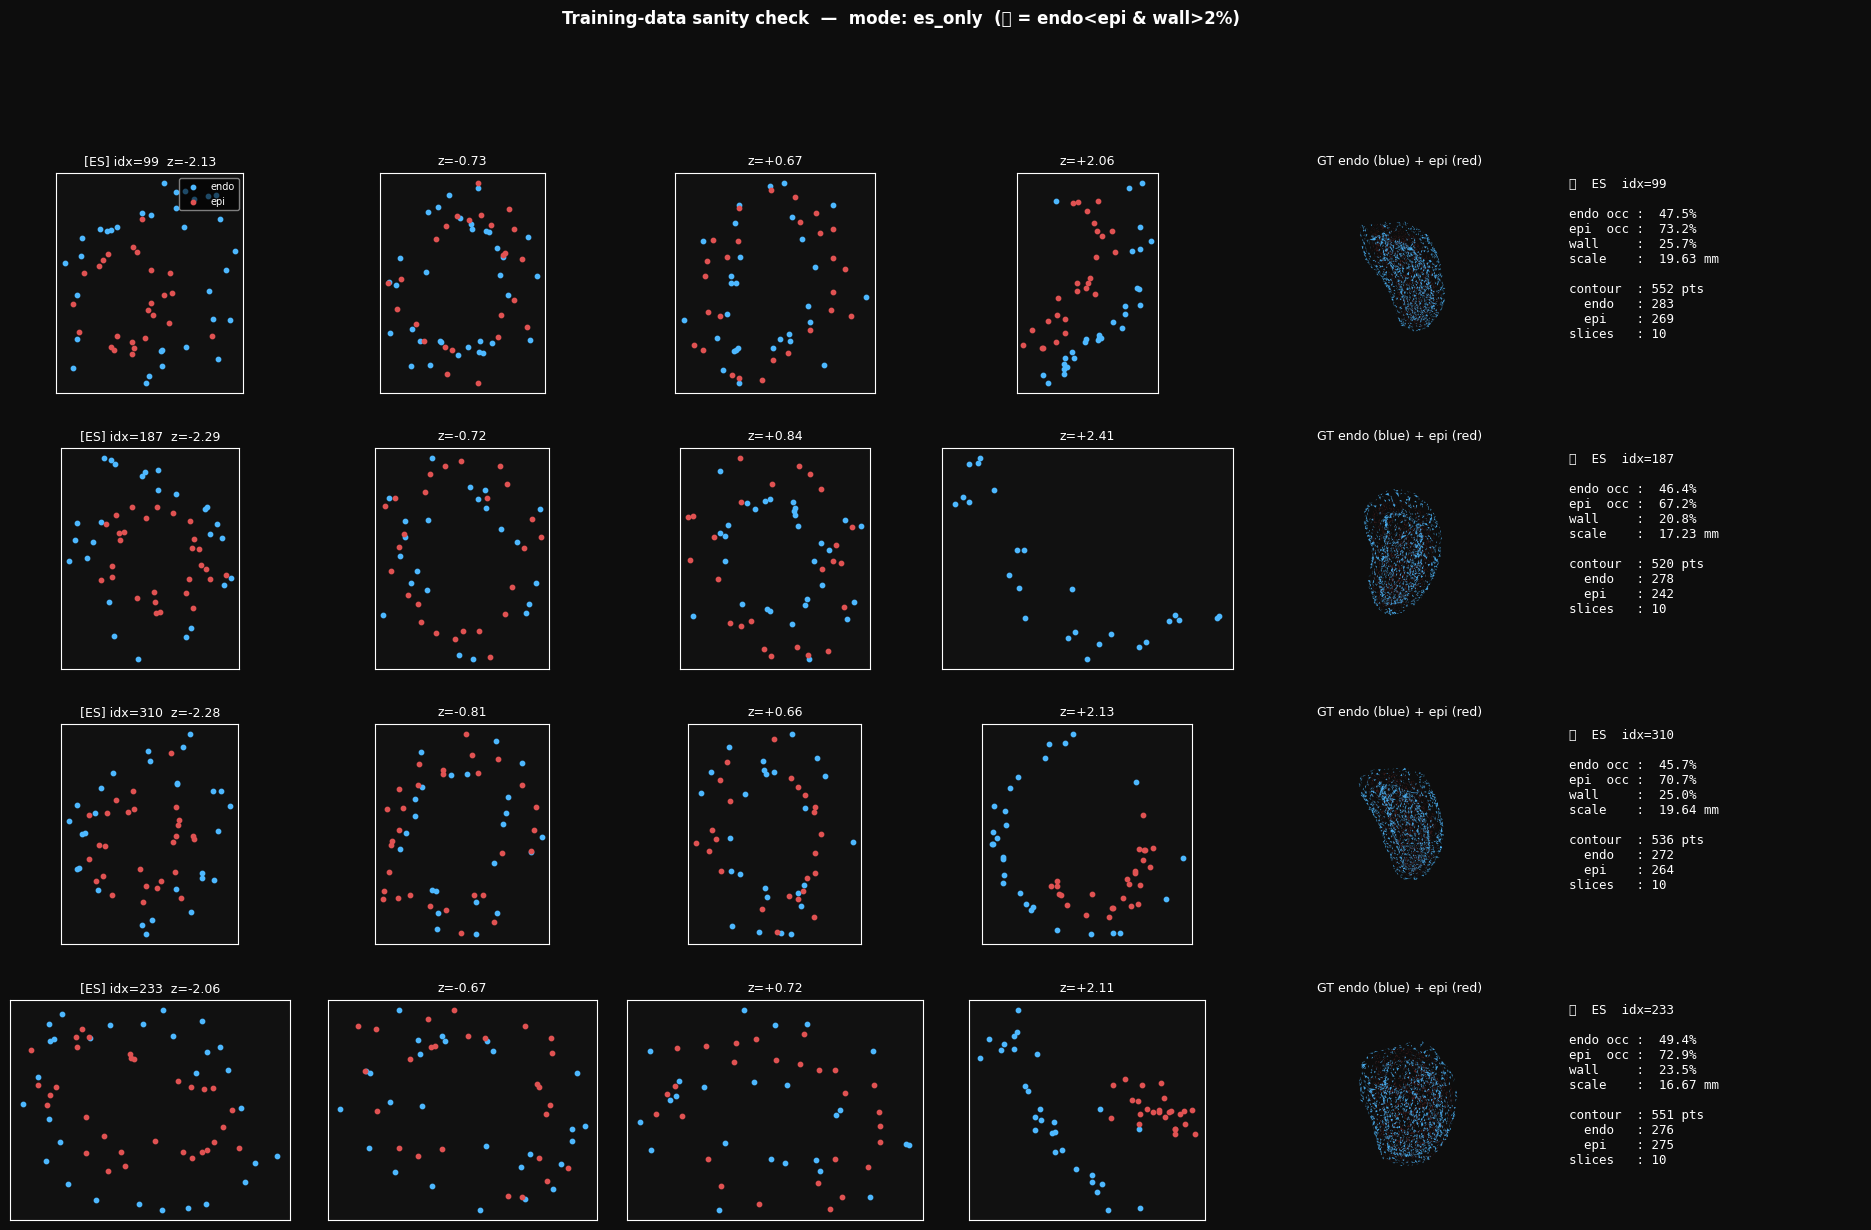


── Aggregate over 64 train samples ──
  endo occ : 47.5% ± 1.9%
  epi  occ : 71.6% ± 2.7%
  wall     : 24.1% ± 1.9%
  samples with epi ≤ endo + 2% : 0/64  ✅ OK


,idx,kind,endo,epi,wall,scale,ok
0,99,ES,0.475098,0.732422,0.257324,19.634727,✅
1,187,ES,0.464355,0.672363,0.208008,17.233061,✅
2,310,ES,0.457031,0.706543,0.249512,19.644884,✅
3,233,ES,0.493652,0.729004,0.235352,16.673706,✅


In [ ]:
# ══════════════════════════════════════════════════════════════
# Sanity-check the training cache:
#   • Tissue-label audit (printed)  — instantly shows if epi missing
#   • SAX slice scatter (endo blue / epi red rings)
#   • GT endo + epi mesh pair  + raw `_slice_mesh_at_z` rings
#     (cyan=endo, yellow=epi)  → bisects adapter vs slicer
#   • Endo / epi / wall occupancy fractions per sample
# Fast: pulls samples directly from `tr_ds` (already pre-cached),
#       no model inference, no heavy meshing.
# ══════════════════════════════════════════════════════════════

def _gt_meshes_from_file(fp):
    """Return (endo_v, endo_f, epi_v, epi_f) in normalised frame, or Nones."""
    d = np.load(fp, allow_pickle=True)
    if 'endo_vertices' in d.files:                       # ED cache
        return (d['endo_vertices'].astype(np.float32),
                d['endo_faces'].astype(np.int64),
                d['epi_vertices'].astype(np.float32),
                d['epi_faces'].astype(np.int64))
    if 'endo_verts' in d.files:                          # ES cache → adapt
        a = adapt_es_sample(d, rng=np.random.default_rng(0))
        if a is None:
            return None, None, None, None
        f = a['faces'].astype(np.int64)
        return a['endo_verts'], f, a['epi_verts'], f
    return None, None, None, None


def _diagnose_one_sample(idx):
    """Pull one training sample and compute summary stats."""
    s        = tr_ds[idx]
    contour  = s['contour']
    xyz, tissue = contour[:, :3], contour[:, 3]
    return dict(
        idx=idx, sample=s, xyz=xyz, tissue=tissue,
        n_endo_pts=int((tissue == 0).sum()),
        n_epi_pts =int((tissue == 1).sum()),
        e_frac=float(s['endo_occ'].mean()),
        p_frac=float(s['epi_occ'].mean()),
        w_frac=float(((s['epi_occ'] > 0.5) & (s['endo_occ'] < 0.5)).mean()),
        is_es=(idx in tr_ds._es_cache),
    )


def inspect_training_samples(n_samples=4, n_slices_show=4, max_faces=2000):
    """Plot SAX slices + GT meshes + occupancy stats for a few train samples.

    Selection: prefers samples that have BOTH endo + epi contour points,
    then includes 1 'missing epi' and 1 'missing endo' sample for contrast.
    Bisection: 3D panel overlays the raw `_slice_mesh_at_z` rings
    (cyan=endo, yellow=epi) so we can tell whether a missing colour is
    caused by the slicer or by the contour-assembly loop.
    """
    rng = np.random.default_rng(0)

    # ── Upfront audit: scan up to 32 samples, print tissue counts ──
    n_audit   = min(32, len(tr_ds))
    audit_idx = rng.choice(len(tr_ds), n_audit, replace=False)
    audit     = [_diagnose_one_sample(int(i)) for i in audit_idx]
    n_no_epi  = sum(1 for a in audit if a['n_epi_pts']  == 0)
    n_no_endo = sum(1 for a in audit if a['n_endo_pts'] == 0)
    print(f'── Tissue-label audit ({n_audit} samples) ──')
    print(f'  no epi  contour pts (tissue==1): {n_no_epi:2d}/{n_audit}'
          f'  {"⚠ EPI MISSING"  if n_no_epi  > 0 else "✅"}')
    print(f'  no endo contour pts (tissue==0): {n_no_endo:2d}/{n_audit}'
          f'  {"⚠ ENDO MISSING" if n_no_endo > 0 else "✅"}')
    print(f'  {"idx":>5}  {"kind":>4}  {"n_endo":>7}  {"n_epi":>6}  '
          f'{"endo%":>6}  {"epi%":>6}  {"wall%":>6}')
    for a in audit[:8]:
        flag = '⚠' if a['n_epi_pts'] == 0 or a['n_endo_pts'] == 0 else '✓'
        print(f'  {a["idx"]:>5}  {("ES" if a["is_es"] else "ED"):>4}  '
              f'{a["n_endo_pts"]:>7}  {a["n_epi_pts"]:>6}  '
              f'{a["e_frac"]*100:>5.1f}  {a["p_frac"]*100:>5.1f}  '
              f'{a["w_frac"]*100:>5.1f}  {flag}')

    # ── Pick samples for plot: prefer those with both colours ────
    have_both    = [a for a in audit if a['n_endo_pts'] > 0 and a['n_epi_pts'] > 0]
    missing_epi  = [a for a in audit if a['n_epi_pts']  == 0]
    missing_endo = [a for a in audit if a['n_endo_pts'] == 0]
    chosen = []
    chosen.extend(have_both[:max(1, n_samples - 2)])
    chosen.extend(missing_epi[:1])
    chosen.extend(missing_endo[:1])
    if len(chosen) < n_samples:
        chosen.extend(have_both[len(chosen):n_samples])
    chosen = chosen[:n_samples] if chosen else audit[:n_samples]
    n = len(chosen)

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(4 * (n_slices_show + 2), 3.4 * n),
                     facecolor='#0d0d0d')
    gs = plt.GridSpec(n, n_slices_show + 2, figure=fig,
                      wspace=0.05, hspace=0.30)

    stats = []
    for row, a in enumerate(chosen):
        idx     = a['idx']
        sample  = a['sample']
        contour = sample['contour']
        scale   = float(sample['scale'])
        xyz, tissue = a['xyz'], a['tissue']
        kind    = 'ES' if a['is_es'] else 'ED'

        ok = '✅' if (a['n_endo_pts'] > 0 and a['n_epi_pts'] > 0
                     and a['p_frac'] > a['e_frac'] + 0.02
                     and a['w_frac'] > 0.02) else '⚠'
        stats.append(dict(idx=idx, kind=kind, endo=a['e_frac'],
                          epi=a['p_frac'], wall=a['w_frac'],
                          n_endo_pts=a['n_endo_pts'],
                          n_epi_pts=a['n_epi_pts'],
                          scale=scale, ok=ok))

        # ── SAX slices (cached contour) ──────────────────────
        z_round = np.round(xyz[:, 2], 4)
        z_uniq  = np.unique(z_round)
        if len(z_uniq) >= n_slices_show:
            z_show = z_uniq[np.linspace(0, len(z_uniq) - 1,
                                        n_slices_show).astype(int)]
        else:
            z_show = z_uniq
        for col, zc in enumerate(z_show):
            ax = fig.add_subplot(gs[row, col], facecolor='#111111')
            m  = z_round == zc
            n_e = int((m & (tissue == 0)).sum())
            n_p = int((m & (tissue == 1)).sum())
            ax.scatter(xyz[m & (tissue == 0), 0], xyz[m & (tissue == 0), 1],
                       c='#4db8ff', s=14, label=f'endo ({n_e})')
            ax.scatter(xyz[m & (tissue == 1), 0], xyz[m & (tissue == 1), 1],
                       c='#e05252', s=14, label=f'epi ({n_p})')
            ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
            ttl = (f'[{kind}] idx={idx}  z={zc:+.2f}  e={n_e} p={n_p}'
                   if col == 0 else f'z={zc:+.2f}  e={n_e} p={n_p}')
            ax.set_title(ttl, color='white', fontsize=9)
            ax.legend(fontsize=7, loc='upper right', framealpha=0.6)

        # ── BISECTION 3D panel: GT meshes + raw mesh slice rings ─
        ax3d = fig.add_subplot(gs[row, n_slices_show],
                               projection='3d', facecolor='#0d0d0d')
        ev, ef, pv, pf = _gt_meshes_from_file(tr_ds.files[idx])
        if ev is not None and len(ef) > 0:
            sel_e = ef[rng.choice(len(ef), min(max_faces, len(ef)), replace=False)]
            ax3d.add_collection3d(Poly3DCollection(
                ev[sel_e], facecolor='#4db8ff', alpha=0.85, edgecolor='none'))
        if pv is not None and len(pf) > 0:
            sel_p = pf[rng.choice(len(pf), min(max_faces, len(pf)), replace=False)]
            ax3d.add_collection3d(Poly3DCollection(
                pv[sel_p], facecolor='#e05252', alpha=0.25, edgecolor='none'))

        endo_ring_n = epi_ring_n = 0
        if ev is not None and pv is not None and len(ef) > 0:
            zc_mid = float((ev[:, 2].min() + ev[:, 2].max()) / 2)
            er = _slice_mesh_at_z(ev, ef, zc_mid, pts_per_ring=60)
            pr = _slice_mesh_at_z(pv, pf, zc_mid, pts_per_ring=60)
            if er is not None:
                endo_ring_n = len(er)
                ax3d.scatter(er[:, 0], er[:, 1],
                             np.full(len(er), zc_mid),
                             c='cyan', s=14, depthshade=False)
            if pr is not None:
                epi_ring_n = len(pr)
                ax3d.scatter(pr[:, 0], pr[:, 1],
                             np.full(len(pr), zc_mid),
                             c='yellow', s=14, depthshade=False)
        all_v = np.vstack([v for v in [ev, pv, xyz] if v is not None and len(v) > 0])
        if len(all_v) > 0:
            cmin, cmax = all_v.min(0), all_v.max(0)
            cc = (cmin + cmax) / 2; ext = (cmax - cmin).max() / 2 * 1.05
            ax3d.set_xlim(cc[0]-ext, cc[0]+ext)
            ax3d.set_ylim(cc[1]-ext, cc[1]+ext)
            ax3d.set_zlim(cc[2]-ext, cc[2]+ext)
            ax3d.set_box_aspect([1, 1, 1])
        ax3d.set_axis_off(); ax3d.view_init(elev=20, azim=60)
        ax3d.set_title(f'GT meshes + raw rings\n'
                       f'cyan={endo_ring_n}pts  yellow={epi_ring_n}pts',
                       color='white', fontsize=9)

        # ── Stats panel ──────────────────────────────────────
        axs = fig.add_subplot(gs[row, n_slices_show + 1], facecolor='#111111')
        axs.axis('off')
        warn = ''
        if a['n_epi_pts'] == 0:
            warn = '\n⚠ NO EPI POINTS\n  raw ring count tells\n  if slicer or adapter'
        elif a['n_endo_pts'] == 0:
            warn = '\n⚠ NO ENDO POINTS'
        elif a['p_frac'] <= a['e_frac']:
            warn = '\n⚠ epi occ ≤ endo occ\n  → adapter swap failed'
        txt = (f'{ok}  {kind}  idx={idx}\n\n'
               f'endo occ : {a["e_frac"]:6.1%}\n'
               f'epi  occ : {a["p_frac"]:6.1%}\n'
               f'wall     : {a["w_frac"]:6.1%}\n'
               f'scale    : {scale:6.2f} mm\n\n'
               f'contour  : {len(contour)} pts\n'
               f'  endo   : {a["n_endo_pts"]}\n'
               f'  epi    : {a["n_epi_pts"]}\n'
               f'slices   : {len(np.unique(np.round(xyz[:,2],4)))}'
               f'{warn}')
        axs.text(0.02, 0.98, txt, color='white', fontsize=9,
                 family='monospace', va='top', ha='left',
                 transform=axs.transAxes)

    fig.suptitle(f'Training-data sanity check  —  mode: {CFG["mode"]}  '
                 f'(✅ = both colours present & wall>2%)',
                 color='white', fontsize=12, fontweight='bold', y=1.00)
    plt.savefig(f'{CFG["output_dir"]}/sanity_train_{CFG["mode"]}.png',
                dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    plt.style.use('default')

    # ── Aggregate occupancy summary across many samples ──────
    n_check = min(64, len(tr_ds))
    agg = []
    for k in rng.choice(len(tr_ds), n_check, replace=False):
        s = tr_ds[int(k)]
        agg.append((float(s['endo_occ'].mean()),
                    float(s['epi_occ'].mean()),
                    float(((s['epi_occ'] > 0.5) & (s['endo_occ'] < 0.5)).mean())))
    agg = np.array(agg)
    n_bad = int(((agg[:, 1] - agg[:, 0]) < 0.02).sum())
    print(f'\n── Aggregate over {n_check} train samples ──')
    print(f'  endo occ : {agg[:,0].mean():.1%} ± {agg[:,0].std():.1%}')
    print(f'  epi  occ : {agg[:,1].mean():.1%} ± {agg[:,1].std():.1%}')
    print(f'  wall     : {agg[:,2].mean():.1%} ± {agg[:,2].std():.1%}')
    print(f'  samples with epi ≤ endo + 2% : {n_bad}/{n_check}  '
          f'{"⚠ ADAPTER ISSUE" if n_bad > n_check * 0.1 else "✅ OK"}')

    return pd.DataFrame(stats)


_sanity_df = inspect_training_samples(n_samples=4, n_slices_show=4)
_sanity_df

## 4. Model Architecture

**PointNetEncoder** — Phase-aware variant (input dim = 4 or 5):
- Shared MLP: `input_dim → 64 → 128 → 256`
- Per-tissue max-pool (endo / epi separately) → 128 each
- Global max-pool → 256
- Concatenate `[g_all, g_endo, g_epi]` → 512 → `latent_dim`

**FourierPE** — `pe(xyz) = [xyz, sin(2^k π xyz), cos(2^k π xyz)]` for `k = 0..L-1`

**INRDecoder** — 8-layer MLP, skip at layer 4, dual heads (endo/epi)

In [6]:

# ══════════════════════════════════════════════════════════════
# PointNet Encoder — phase-aware (input_dim = 4 or 5)
# ══════════════════════════════════════════════════════════════

class PointNetEncoder(nn.Module):
    """Processes variable-size SAX contour cloud → fixed-size latent code.

    Input : (B, N, input_dim)  — [x, y, z, tissue] or [x, y, z, tissue, phase]
    Mask  : (B, N)             — True for real points, False for padding
    Output: (B, latent_dim)
    """

    def __init__(self, input_dim=4, latent_dim=256):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Linear(input_dim, 64),  nn.LayerNorm(64),  nn.ReLU())
        self.conv2 = nn.Sequential(nn.Linear(64, 128),        nn.LayerNorm(128), nn.ReLU())
        self.conv3 = nn.Sequential(nn.Linear(128, 256),       nn.LayerNorm(256), nn.ReLU())

        # Per-tissue projection: separates endo from epi features
        self.tissue_proj = nn.Sequential(nn.Linear(256, 128), nn.ReLU())

        # Aggregation: global(256) + endo(128) + epi(128) = 512
        self.agg = nn.Sequential(
            nn.Linear(512, 512), nn.LayerNorm(512), nn.ReLU(),
            nn.Linear(512, latent_dim))

    def forward(self, x, mask):
        B, N, _ = x.shape
        h = self.conv1(x)   # (B, N, 64)
        h = self.conv2(h)   # (B, N, 128)
        h = self.conv3(h)   # (B, N, 256)

        # Global max-pool (masked)
        neg_inf  = torch.full_like(h, float('-inf'))
        h_masked = torch.where(mask.unsqueeze(-1), h, neg_inf)
        g_all    = h_masked.max(dim=1).values   # (B, 256)

        # Per-tissue max-pool — tissue label is always column 3
        tissue = x[:, :, 3]
        hp     = self.tissue_proj(h)           # (B, N, 128)

        def tissue_pool(label):
            t_mask = (tissue == label) & mask
            t_neg  = torch.full_like(hp, float('-inf'))
            t_h    = torch.where(t_mask.unsqueeze(-1), hp, t_neg)
            pooled = t_h.max(dim=1).values
            has_pts = t_mask.any(dim=1, keepdim=True).float()
            return pooled * has_pts

        g_endo = tissue_pool(0.0)   # (B, 128)
        g_epi  = tissue_pool(1.0)   # (B, 128)

        cat = torch.cat([g_all, g_endo, g_epi], dim=-1)   # (B, 512)
        return self.agg(cat)                               # (B, latent_dim)


# ══════════════════════════════════════════════════════════════
# Fourier Positional Encoding
# ══════════════════════════════════════════════════════════════

class FourierPE(nn.Module):
    """pe(xyz) = [xyz, sin(2^k π xyz), cos(2^k π xyz)] for k=0..L-1"""

    def __init__(self, L=6):
        super().__init__()
        self.L = L
        self.register_buffer('freqs', 2.0 ** torch.arange(L).float() * np.pi)
        self.out_dim = 3 + 6 * L

    def forward(self, xyz):
        angles = xyz.unsqueeze(-1) * self.freqs       # (..., 3, L)
        enc    = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        enc    = enc.reshape(*xyz.shape[:-1], 6 * self.L)
        return torch.cat([xyz, enc], dim=-1)


# ══════════════════════════════════════════════════════════════
# INR Decoder — 8-layer MLP with skip connection
# ══════════════════════════════════════════════════════════════

class INRDecoder(nn.Module):
    """8-layer MLP with skip connection at layer 4. Dual output heads."""

    def __init__(self, latent_dim=256, fourier_L=6,
                 hidden=512, n_layers=8, skip_layer=4):
        super().__init__()
        self.skip_layer = skip_layer
        pe_dim = 3 + 6 * fourier_L
        in_dim = latent_dim + pe_dim

        layers = []
        cur_dim = in_dim
        for i in range(n_layers):
            if i == skip_layer:
                cur_dim += in_dim
            layers.append(nn.Linear(cur_dim, hidden))
            layers.append(nn.LayerNorm(hidden))
            layers.append(nn.ReLU())
            cur_dim = hidden
        self.layers = nn.ModuleList(layers)

        self.head_endo = nn.Linear(hidden, 1)
        self.head_epi  = nn.Linear(hidden, 1)
        self._in_dim   = in_dim

        # Initialise heads near zero → sigmoid starts at ~0.5
        nn.init.normal_(self.head_endo.weight, std=1e-4)
        nn.init.zeros_(self.head_endo.bias)
        nn.init.normal_(self.head_epi.weight,  std=1e-4)
        nn.init.zeros_(self.head_epi.bias)

    def forward(self, z, pe_xyz):
        B, Q, _ = pe_xyz.shape
        z_exp = z.unsqueeze(1).expand(-1, Q, -1)
        inp   = torch.cat([z_exp, pe_xyz], dim=-1)

        h    = inp
        step = 0
        for j in range(0, len(self.layers), 3):
            if step == self.skip_layer:
                h = torch.cat([h, inp], dim=-1)
            h    = self.layers[j](h)     # Linear
            h    = self.layers[j+1](h)   # LayerNorm
            h    = self.layers[j+2](h)   # ReLU
            step += 1

        return self.head_endo(h).squeeze(-1), self.head_epi(h).squeeze(-1)


# ══════════════════════════════════════════════════════════════
# Full Occupancy Network
# ══════════════════════════════════════════════════════════════

class OccupancyNetwork(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = PointNetEncoder(
            input_dim=cfg['input_dim'],
            latent_dim=cfg['latent_dim'])
        self.fourier = FourierPE(L=cfg['fourier_L'])
        self.decoder = INRDecoder(
            latent_dim=cfg['latent_dim'],
            fourier_L=cfg['fourier_L'],
            hidden=cfg['decoder_hidden'],
            n_layers=cfg['decoder_layers'],
            skip_layer=cfg['skip_layer'])

    def encode(self, contour, mask):
        return self.encoder(contour, mask)

    def decode(self, z, query_xyz):
        pe = self.fourier(query_xyz)
        return self.decoder(z, pe)

    def forward(self, contour, mask, query_xyz):
        z = self.encode(contour, mask)
        endo_logit, epi_logit = self.decode(z, query_xyz)
        return endo_logit, epi_logit, z

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ── Build model ──────────────────────────────────────────────
model = OccupancyNetwork(CFG).to(DEVICE)

# DataParallel for multi-GPU (Kaggle-compatible — no torchrun needed)
if N_GPUS > 1:
    model = nn.DataParallel(model)
    print(f'✅ DataParallel enabled on {N_GPUS} GPUs')

# Access the underlying model for inference
_model = model.module if isinstance(model, nn.DataParallel) else model

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print(f'  Input dim : {CFG["input_dim"]}')
print(f'  Encoder   : {sum(p.numel() for p in _model.encoder.parameters()):,}')
print(f'  Decoder   : {sum(p.numel() for p in _model.decoder.parameters()):,}')


✅ DataParallel enabled on 2 GPUs
Model parameters: 2,620,866
  Input dim : 4
  Encoder   : 470,464
  Decoder   : 2,150,402


## 5. Loss Function — Dice + BCE + Anatomical Constraints

**Improvements over v1:**
1. **Dice loss** added alongside BCE — better for imbalanced occupancy (typically 30% inside / 70% outside)
2. **Progressive latent regularisation** — linearly ramp `λ_prior` over first 100 epochs (prevents early collapse)
3. All v1 constraints preserved: boundary-weighted BCE, epi⊇endo consistency, wall thickness regularisation

In [7]:
def dice_loss(logit, target, smooth=1.0):
    """Soft Dice loss — works in probability space."""
    prob = torch.sigmoid(logit)
    inter = (prob * target).sum(dim=-1)
    union = prob.sum(dim=-1) + target.sum(dim=-1)
    return 1.0 - (2.0 * inter + smooth) / (union + smooth)


def occupancy_loss(endo_logit, epi_logit, endo_occ, epi_occ,
                   epoch=0, cfg=None):
    """Combined Dice + BCE loss with anatomical constraints.

    Components:
    1. Dice loss (endo + epi) — handles class imbalance
    2. Boundary-weighted BCE (endo + epi) — sharpen iso-surface
    3. Epi ⊇ Endo consistency — anatomical hard constraint
    4. Wall thickness regularisation — prevent collapsed wall
    5. (Optional) Progressive latent regularisation — applied externally

    Returns: (total_loss, endo_bce_scalar, epi_bce_scalar)
    """
    if cfg is None:
        cfg = CFG

    # ── 1. Dice loss ─────────────────────────────────────────
    dice_endo = dice_loss(endo_logit, endo_occ).mean()
    dice_epi  = dice_loss(epi_logit,  epi_occ).mean()
    l_dice = cfg['dice_weight'] * (dice_endo + dice_epi)

    # ── 2. Boundary-weighted BCE ─────────────────────────────
    bce_endo = F.binary_cross_entropy_with_logits(
        endo_logit, endo_occ, reduction='none')
    bce_epi  = F.binary_cross_entropy_with_logits(
        epi_logit,  epi_occ,  reduction='none')

    # Boundary weight: points near 0.5 get 3× weight
    w_endo = 1.0 + 2.0 * (endo_occ - 0.5).abs().lt(0.4).float()
    w_epi  = 1.0 + 2.0 * (epi_occ  - 0.5).abs().lt(0.4).float()

    l_bce = cfg['bce_weight'] * (
        (bce_endo * w_endo).mean() + (bce_epi * w_epi).mean())

    # ── 3. Epi ⊇ Endo consistency ────────────────────────────
    p_endo = torch.sigmoid(endo_logit)
    p_epi  = torch.sigmoid(epi_logit)
    consistency = F.relu(p_endo - p_epi).mean()

    # ── 4. Wall thickness regularisation ──────────────────────
    gt_wall_mask = (epi_occ > 0.5) & (endo_occ < 0.5)
    if gt_wall_mask.sum() > 0:
        pred_wall = (p_epi - p_endo)[gt_wall_mask]
        wall_reg  = F.relu(0.1 - pred_wall).mean()
    else:
        wall_reg = torch.tensor(0.0, device=endo_logit.device)

    # ── Combined ─────────────────────────────────────────────
    loss = (l_dice + l_bce
            + cfg['consistency_w'] * consistency
            + cfg['wall_reg_w'] * wall_reg)

    return loss, bce_endo.mean().item(), bce_epi.mean().item()


print('✅ Loss function defined (Dice + BCE + consistency + wall reg)')

✅ Loss function defined (Dice + BCE + consistency + wall reg)


## 6. Training Loop

- **Mixed precision** (AMP) on CUDA for T4 tensor core acceleration
- **DataParallel** across 2× T4 GPUs
- **Gradient clipping** (max_norm=1.0) for stability
- **CosineAnnealingLR** scheduler
- **Early stopping** with patience
- **Progressive latent regularisation** warm-up

In [8]:

# ── Verify GPU setup ─────────────────────────────────────────
assert DEVICE.type == 'cuda', f'❌ DEVICE is {DEVICE}, expected cuda! Check GPU attachment.'
assert N_GPUS >= 1, f'❌ No GPUs detected! torch.cuda.device_count()={N_GPUS}'
if N_GPUS >= 2:
    assert isinstance(model, nn.DataParallel), '❌ Model not wrapped in DataParallel!'
print(f'✅ GPU check passed: {N_GPUS} GPU(s), DEVICE={DEVICE}')
for i in range(N_GPUS):
    mem = torch.cuda.memory_allocated(i) / 1e9
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}  mem={mem:.2f} GB')

optimizer = torch.optim.AdamW(model.parameters(),
                              lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'] // 5, eta_min=CFG['lr'] * 0.01)

use_amp = (DEVICE.type == 'cuda')
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

best_val, no_improve, best_epoch = float('inf'), 0, 0
history = []
ckpt_path = f'{CFG["output_dir"]}/inr_{CFG["mode"]}.pt'

print(f'\nTraining Occupancy Network — Mode: {CFG["mode"]}')
print(f'  Epochs: {CFG["epochs"]}  |  Batch: {EFF_BS} ({CFG["batch_size"]}×{max(1,N_GPUS)})')
print(f'  AMP: {use_amp}  |  GPUs: {N_GPUS}  |  Grad accum: {CFG["grad_accum"]}')
print(f'  Checkpoint: {ckpt_path}')
print('-' * 100)
print(f'{"Epoch":>6}  {"Tr Loss":>9}  {"Tr Endo":>9}  {"Tr Epi":>8}  '
      f'{"Val Loss":>9}  {"Val Endo":>9}  {"Val Epi":>8}  {"LR":>9}  Note')
print('-' * 100)

t0 = time.time()
for epoch in range(CFG['epochs']):

    # ── Progressive latent regularisation ─────────────────────
    lat_reg_w = CFG['latent_reg_max'] * min(1.0, epoch / max(1, CFG['latent_reg_warmup']))

    # ══ Train ═════════════════════════════════════════════════
    model.train()
    tr_loss = tr_endo = tr_epi = 0.0
    n_tr = 0

    for step, batch in enumerate(tqdm(tr_loader, desc=f'Ep {epoch:3d}', leave=False)):
        contour = batch['contour'].to(DEVICE, non_blocking=True)
        mask    = batch['contour_mask'].to(DEVICE, non_blocking=True)
        query   = batch['query'].to(DEVICE, non_blocking=True)
        e_occ   = batch['endo_occ'].to(DEVICE, non_blocking=True)
        p_occ   = batch['epi_occ'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            e_logit, p_logit, z = model(contour, mask, query)
            loss, l_e, l_p   = occupancy_loss(
                e_logit, p_logit, e_occ, p_occ, epoch=epoch, cfg=CFG)

            # Progressive latent regularisation (lightweight: penalise large latents)
            if lat_reg_w > 0:
                z_reg = lat_reg_w * z.pow(2).mean()
                loss = loss + z_reg

            loss = loss / CFG['grad_accum']

        scaler.scale(loss).backward()

        if (step + 1) % CFG['grad_accum'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        bs = contour.shape[0]
        tr_loss += loss.item() * CFG['grad_accum'] * bs
        tr_endo += l_e * bs
        tr_epi  += l_p * bs
        n_tr    += bs

        # GPU diagnostics on very first batch
        if epoch == 0 and step == 0:
            print(f'\n  ✅ First batch processed! shape={contour.shape}, device={contour.device}')
            for gi in range(N_GPUS):
                alloc = torch.cuda.memory_allocated(gi) / 1e9
                peak  = torch.cuda.max_memory_allocated(gi) / 1e9
                print(f'  GPU {gi}: alloc={alloc:.2f} GB  peak={peak:.2f} GB')
            print()

    # Flush remaining gradients
    if n_tr > 0 and (step + 1) % CFG['grad_accum'] != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    tr_loss /= max(n_tr, 1); tr_endo /= max(n_tr, 1); tr_epi /= max(n_tr, 1)

    # ══ Validate ══════════════════════════════════════════════
    model.eval()
    va_loss = va_endo = va_epi = 0.0
    n_va = 0

    with torch.no_grad():
        for batch in val_loader:
            contour = batch['contour'].to(DEVICE, non_blocking=True)
            mask    = batch['contour_mask'].to(DEVICE, non_blocking=True)
            query   = batch['query'].to(DEVICE, non_blocking=True)
            e_occ   = batch['endo_occ'].to(DEVICE, non_blocking=True)
            p_occ   = batch['epi_occ'].to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                e_logit, p_logit, _ = model(contour, mask, query)
                loss, l_e, l_p   = occupancy_loss(
                    e_logit, p_logit, e_occ, p_occ, epoch=epoch, cfg=CFG)

            bs = contour.shape[0]
            va_loss += loss.item() * bs
            va_endo += l_e * bs
            va_epi  += l_p * bs
            n_va    += bs

    va_loss /= max(n_va, 1); va_endo /= max(n_va, 1); va_epi /= max(n_va, 1)

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history.append(dict(
        epoch=epoch, tr_loss=tr_loss, tr_endo=tr_endo, tr_epi=tr_epi,
        va_loss=va_loss, va_endo=va_endo, va_epi=va_epi, lr=lr_now,
        lat_reg=lat_reg_w))

    # ── Checkpoint (with NaN guard, always-on print) ──────────
    note = ''
    if not np.isfinite(va_loss):
        note = '  ⚠ non-finite val_loss (skip ckpt)'
        no_improve += 1
    elif va_loss < best_val:
        best_val, best_epoch, no_improve = va_loss, epoch, 0
        torch.save({
            'epoch': epoch, 'model_state': _model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss': va_loss, 'cfg': CFG, 'history': history,
        }, ckpt_path)
        note = f'  ← BEST (saved {Path(ckpt_path).name})'
    else:
        no_improve += 1

    # Print every epoch — guarantees val loss is always visible
    print(f'{epoch:6d}  {tr_loss:9.4f}  {tr_endo:9.4f}  {tr_epi:8.4f}  '
          f'{va_loss:9.4f}  {va_endo:9.4f}  {va_epi:8.4f}  {lr_now:9.2e}{note}')

    if no_improve >= CFG['patience']:
        print(f'\nEarly stopping at epoch {epoch}  (patience={CFG["patience"]})')
        break

elapsed = time.time() - t0
print(f'\n{"═"*70}')
print(f'  Best val_loss = {best_val:.4f}  at epoch {best_epoch}')
print(f'  Total time    = {elapsed/60:.1f} min  ({elapsed/3600:.1f} h)')
print(f'  Checkpoint    = {ckpt_path}')
print(f'{"═"*70}')


✅ GPU check passed: 2 GPU(s), DEVICE=cuda
  GPU 0: Tesla T4  mem=0.01 GB
  GPU 1: Tesla T4  mem=0.00 GB

Training Occupancy Network — Mode: es_only
  Epochs: 500  |  Batch: 32 (16×2)
  AMP: True  |  GPUs: 2  |  Grad accum: 1
  Checkpoint: /kaggle/working/inr_es_only.pt
----------------------------------------------------------------------------------------------------
 Epoch    Tr Loss    Tr Endo    Tr Epi   Val Loss   Val Endo   Val Epi         LR  Note
----------------------------------------------------------------------------------------------------


Ep   0:   0%|          | 0/12 [00:00<?, ?it/s]


  ✅ First batch processed! shape=torch.Size([32, 593, 4]), device=cuda:0
  GPU 0: alloc=0.02 GB  peak=1.59 GB
  GPU 1: alloc=0.01 GB  peak=1.59 GB

     0     2.2798     0.6956    0.6732     2.2135     0.7027    0.6443   1.00e-04  ← BEST (saved inr_es_only.pt)


Ep   1:   0%|          | 0/12 [00:00<?, ?it/s]

     1     2.1757     0.7078    0.6273     2.1269     0.7067    0.6097   9.99e-05  ← BEST (saved inr_es_only.pt)


...

     9     1.8507     0.6073    0.5806     1.8334     0.5954    0.5778   9.76e-05  ← BEST (saved inr_es_only.pt)


Ep  10:   0%|          | 0/12 [00:00<?, ?it/s]

    10     1.8318     0.5955    0.5783     1.8264     0.5894    0.5732   9.71e-05  ← BEST (saved inr_es_only.pt)


Ep  11:   0%|          | 0/12 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 7. Training Curves

In [ ]:
hdf = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cols = ['#2c3e50', '#e74c3c']

for ax, (tr_col, va_col, title) in zip(axes, [
    ('tr_loss', 'va_loss', 'Total Loss (Dice + BCE)'),
    ('tr_endo', 'va_endo', 'Endo BCE'),
    ('tr_epi',  'va_epi',  'Epi BCE'),
]):
    ax.plot(hdf.epoch, hdf[tr_col], color=cols[0], alpha=0.5, lw=1.5, label='Train')
    ax.plot(hdf.epoch, hdf[va_col], color=cols[1], lw=2.0, label='Val')
    ax.axvline(best_epoch, color='#7f8c8d', ls='--', lw=1.2, alpha=0.7,
               label=f'Best (ep {best_epoch})')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(title, fontweight='bold')
    ax.legend(framealpha=0.9, edgecolor='none')
    ax.grid(alpha=0.25, ls=':')
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

fig.suptitle(f'Training Convergence — {CFG["mode"]} mode', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{CFG["output_dir"]}/training_curves_{CFG["mode"]}.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 8. Inference & Evaluation

Load best checkpoint, run marching cubes on test set, compute:
- **Chamfer distance** (endo + epi) in mm
- **Wall thickness** mean ± std

In [ ]:
# ── Load best checkpoint ──────────────────────────────────────
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
_model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'✅ Loaded best checkpoint — epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')


def predict_mesh(model_net, contour_xyz, tissue_labels, cfg,
                 grid_res=None, iso_thresh=None, batch_query=131072,
                 phase_val=None):
    """Run occupancy network on a dense voxel grid → marching cubes → meshes.

    Parameters
    ----------
    phase_val : float or None — if not None, append as 5th feature column
    """
    if grid_res   is None: grid_res   = cfg['grid_res']
    if iso_thresh is None: iso_thresh = cfg['iso_thresh']

    mdl = model_net.module if isinstance(model_net, nn.DataParallel) else model_net
    mdl.eval()

    # Build encoder input
    cont = np.column_stack([contour_xyz, tissue_labels]).astype(np.float32)
    if phase_val is not None and cfg['input_dim'] == 5:
        phase_col = np.full((len(cont), 1), phase_val, dtype=np.float32)
        cont = np.column_stack([cont, phase_col])

    cont_t = torch.from_numpy(cont).unsqueeze(0).to(DEVICE)
    mask_t = torch.ones(1, len(cont), dtype=torch.bool).to(DEVICE)

    with torch.no_grad():
        z = mdl.encode(cont_t, mask_t)

    # Dense query grid
    lo = contour_xyz.min(0) - 0.15
    hi = contour_xyz.max(0) + 0.15
    xs = np.linspace(lo[0], hi[0], grid_res)
    ys = np.linspace(lo[1], hi[1], grid_res)
    zs = np.linspace(lo[2], hi[2], grid_res)
    gx, gy, gz = np.meshgrid(xs, ys, zs, indexing='ij')
    grid_pts = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=-1).astype(np.float32)

    endo_logits = np.zeros(len(grid_pts), np.float32)
    epi_logits  = np.zeros(len(grid_pts), np.float32)

    for start in range(0, len(grid_pts), batch_query):
        pts = torch.from_numpy(grid_pts[start:start+batch_query]).unsqueeze(0).to(DEVICE)
        with torch.no_grad(), torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
            el, pl = mdl.decode(z, pts)
        endo_logits[start:start+batch_query] = el[0].float().cpu().numpy()
        epi_logits[ start:start+batch_query] = pl[0].float().cpu().numpy()

    occ_endo = torch.sigmoid(torch.from_numpy(endo_logits)).numpy().reshape(grid_res, grid_res, grid_res)
    occ_epi  = torch.sigmoid(torch.from_numpy(epi_logits)).numpy().reshape(grid_res, grid_res, grid_res)

    voxel_size = (hi - lo) / (grid_res - 1)

    def vol_to_mesh(occ):
        if occ.max() < iso_thresh:
            return trimesh.Trimesh()
        try:
            verts, faces, _, _ = marching_cubes(occ, level=iso_thresh, spacing=voxel_size)
            verts = verts + lo
            mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=True)
            components = mesh.split(only_watertight=False)
            if len(components) > 1:
                mesh = max(components, key=lambda m: len(m.faces))
            return mesh
        except Exception:
            return trimesh.Trimesh()

    return vol_to_mesh(occ_endo), vol_to_mesh(occ_epi), occ_endo, occ_epi


def compute_wall_thickness(endo_mesh, epi_mesh, n_samples=2000):
    """Estimate wall thickness via ray-casting from endo → epi."""
    if len(endo_mesh.vertices) == 0 or len(epi_mesh.vertices) == 0:
        return np.array([]), np.array([]).reshape(0, 3)
    pts, face_idx = trimesh.sample.sample_surface(endo_mesh, n_samples)
    normals = endo_mesh.face_normals[face_idx]
    ray_origins = pts + normals * 0.01
    locs, idx_ray, _ = epi_mesh.ray.intersects_location(
        ray_origins=ray_origins, ray_directions=normals, multiple_hits=False)
    if len(idx_ray) == 0:
        return np.array([]), np.array([]).reshape(0, 3)
    return np.linalg.norm(locs - ray_origins[idx_ray], axis=1), ray_origins[idx_ray]


def chamfer_distance(pts_a, pts_b, n_sample=50000):
    """Symmetric Chamfer distance."""
    if len(pts_a) == 0 or len(pts_b) == 0:
        return float('nan')
    rng = np.random.default_rng(0)
    a = pts_a[rng.choice(len(pts_a), min(n_sample, len(pts_a)), replace=False)]
    b = pts_b[rng.choice(len(pts_b), min(n_sample, len(pts_b)), replace=False)]
    tree_b = KDTree(b)
    tree_a = KDTree(a)
    d_ab = tree_b.query(a)[0].mean()
    d_ba = tree_a.query(b)[0].mean()
    return float((d_ab + d_ba) / 2)


# ── Evaluate on test set ──────────────────────────────────────
def evaluate_test(loader, n_samples=20, eval_grid_res=48):
    """Run inference + Chamfer on `n_samples` test cases.

    Uses a 48³ grid by default for speed (~6× fewer queries than 64³).
    Reports per-phase metrics in `combined` mode so ED vs ES quality
    can be compared directly.
    """
    results = []
    count = 0
    t0 = time.time()

    for batch in loader:
        for b in range(batch['contour'].shape[0]):
            if count >= n_samples:
                break

            cont   = batch['contour'][b].numpy()
            mask   = batch['contour_mask'][b].numpy()
            scale  = batch['scale'][b].item()
            xyz_n  = cont[mask, :3]
            tissue = cont[mask, 3]

            # Detect phase from 5th column if present
            phase_val = None
            if cont.shape[1] == 5:
                phase_val = float(cont[mask, 4][0])

            e_mesh, p_mesh, _, _ = predict_mesh(
                model, xyz_n, tissue, CFG,
                grid_res=eval_grid_res, batch_query=131072,
                phase_val=phase_val)

            # GT from query occupancy
            qpts  = batch['query'][b].numpy()
            e_occ = batch['endo_occ'][b].numpy()
            p_occ = batch['epi_occ'][b].numpy()
            gt_endo = qpts[e_occ > 0.5]
            gt_epi  = qpts[p_occ > 0.5]

            e_cham = chamfer_distance(
                e_mesh.vertices, gt_endo) * scale if len(gt_endo) > 0 else float('nan')
            p_cham = chamfer_distance(
                p_mesh.vertices, gt_epi) * scale if len(gt_epi) > 0 else float('nan')

            wt, _ = compute_wall_thickness(e_mesh, p_mesh)
            wt_mm = wt * scale

            results.append(dict(
                endo_chamfer = e_cham,
                epi_chamfer  = p_cham,
                wt_mean = float(wt_mm.mean()) if len(wt_mm) > 0 else float('nan'),
                wt_std  = float(wt_mm.std())  if len(wt_mm) > 0 else float('nan'),
                phase   = phase_val,
            ))
            count += 1
        if count >= n_samples:
            break

    df = pd.DataFrame(results)
    dt = time.time() - t0
    print(f'\n── Evaluation Results ({CFG["mode"]} mode, grid={eval_grid_res}³, {dt:.1f}s) ─')
    print(f'  Samples          : {len(df)}')
    print(f'  Endo Chamfer (mm): {df.endo_chamfer.mean():.3f} ± {df.endo_chamfer.std():.3f}')
    print(f'  Epi  Chamfer (mm): {df.epi_chamfer.mean():.3f} ± {df.epi_chamfer.std():.3f}')
    print(f'  Wall thickness   : {df.wt_mean.mean():.2f} ± {df.wt_mean.std():.2f} mm')

    # Per-phase breakdown for combined mode
    if df['phase'].notna().any() and df['phase'].nunique() > 1:
        for ph_val, ph_name in [(0.0, 'ED'), (1.0, 'ES')]:
            sub = df[df['phase'] == ph_val]
            if len(sub) > 0:
                print(f'  [{ph_name}] n={len(sub):2d}  '
                      f'endo={sub.endo_chamfer.mean():.3f}  '
                      f'epi={sub.epi_chamfer.mean():.3f}  '
                      f'wt={sub.wt_mean.mean():.2f}')
    print('────────────────────────────────────────────────────────')
    return df


eval_df = evaluate_test(te_loader, n_samples=20)


## 9. Visualisation — 3D Mesh Reconstruction

In [ ]:
def _set_ax_lim(ax, vertices, margin=0.05):
    if vertices is None or len(vertices) == 0:
        return
    vmin = vertices.min(axis=0); vmax = vertices.max(axis=0)
    center = (vmin + vmax) / 2; extent = (vmax - vmin).max() / 2 * (1 + margin)
    ax.set_xlim(center[0]-extent, center[0]+extent)
    ax.set_ylim(center[1]-extent, center[1]+extent)
    ax.set_zlim(center[2]-extent, center[2]+extent)
    ax.set_box_aspect([1, 1, 1])


def visualise_prediction(sample_idx=0, viz_grid_res=48):
    """Visualise one test sample.

    Uses a smaller grid (default 48³) for marching cubes — keeps viz
    snappy without affecting evaluation quality elsewhere.
    Handles ED and ES caches uniformly: for ES, the GT meshes are
    re-normalised through `adapt_es_sample` so they share the
    coordinate frame of the predicted meshes.
    """
    idx = te_idx[sample_idx]
    fp  = files[idx]
    d   = np.load(fp, allow_pickle=True)

    # ── Build contour + GT in the SAME normalised frame ──────
    if 'contour' in d.files and 'query' in d.files:
        # ED-format cache (everything already normalised)
        contour     = d['contour'].astype(np.float32)
        scale       = float(d['scale'])
        gt_endo_v   = d['endo_vertices'].astype(np.float32) if 'endo_vertices' in d.files else np.empty((0, 3), np.float32)
        gt_endo_f   = d['endo_faces'].astype(np.int64)      if 'endo_faces'    in d.files else np.empty((0, 3), np.int64)
        gt_epi_v    = d['epi_vertices'].astype(np.float32)  if 'epi_vertices'  in d.files else np.empty((0, 3), np.float32)
        gt_epi_f    = d['epi_faces'].astype(np.int64)       if 'epi_faces'     in d.files else np.empty((0, 3), np.int64)
        sample_kind = 'ED'
    else:
        # ES-format cache → adapt (gives normalised verts + faces)
        adapted = adapt_es_sample(d, rng=np.random.default_rng(123 + sample_idx))
        if adapted is None:
            print(f'Cannot visualise sample {sample_idx}'); return
        contour   = adapted['contour']
        scale     = float(adapted['scale'])
        gt_endo_v = adapted['endo_verts']
        gt_endo_f = adapted['faces'].astype(np.int64)
        gt_epi_v  = adapted['epi_verts']
        gt_epi_f  = adapted['faces'].astype(np.int64)   # ES: shared topology
        sample_kind = 'ES'

    xyz_n  = contour[:, :3]
    tissue = contour[:, 3]

    phase_val = None
    if CFG['mode'] == 'combined' and phase_labels is not None:
        phase_val = phase_labels[idx]

    # ── Predict (smaller grid for speed) ─────────────────────
    t_pred = time.time()
    endo_mesh, epi_mesh, occ_endo, occ_epi = predict_mesh(
        model, xyz_n, tissue, CFG,
        grid_res=viz_grid_res, batch_query=131072, phase_val=phase_val)
    dt_pred = time.time() - t_pred

    thickness, _ = compute_wall_thickness(endo_mesh, epi_mesh)

    # ── Figure ────────────────────────────────────────────────
    plt.style.use('dark_background')
    fig = plt.figure(figsize=(28, 8), facecolor='#0d0d0d')
    phase_str = sample_kind if phase_val is None else ('ED' if phase_val == 0.0 else 'ES')
    fig.suptitle(f'LV Reconstruction — Test {sample_idx}  ({phase_str}, '
                 f'{CFG["mode"]} mode, grid={viz_grid_res}³, {dt_pred:.1f}s)',
                 fontsize=13, fontweight='bold', color='white', y=1.02)
    gs = plt.GridSpec(1, 6, figure=fig, wspace=0.04)

    def _mesh(ax, verts, faces, color, alpha, max_f=3000):
        if len(faces) == 0: return
        sel = faces[np.random.choice(len(faces), min(max_f, len(faces)), replace=False)]
        ax.add_collection3d(Poly3DCollection(verts[sel], alpha=alpha,
                                              facecolor=color, edgecolor='none'))

    def _ax(col, title):
        ax = fig.add_subplot(gs[col], projection='3d', facecolor='#0d0d0d')
        ax.set_title(title, color='white', fontsize=9, pad=8, fontweight='bold')
        ax.set_axis_off(); ax.view_init(elev=20, azim=60)
        return ax

    pieces = []
    if len(endo_mesh.vertices) > 0: pieces.append(endo_mesh.vertices)
    if len(epi_mesh.vertices)  > 0: pieces.append(epi_mesh.vertices)
    if len(gt_endo_v)         > 0: pieces.append(gt_endo_v)
    if len(gt_epi_v)          > 0: pieces.append(gt_epi_v)
    pieces.append(xyz_n)
    all_pts = np.vstack(pieces)

    # 0: Input contours
    ax = _ax(0, f'Input SAX Contours ({sample_kind})')
    ax.scatter(*xyz_n[tissue==0].T, c='#4db8ff', s=6, alpha=0.9)
    ax.scatter(*xyz_n[tissue==1].T, c='#e05252', s=6, alpha=0.9)
    _set_ax_lim(ax, xyz_n)

    # 1: Predicted endo
    ax = _ax(1, f'Pred Endo ({len(endo_mesh.vertices)}v)')
    if len(endo_mesh.vertices) > 0:
        _mesh(ax, endo_mesh.vertices, endo_mesh.faces, '#4db8ff', 0.85)
        _set_ax_lim(ax, endo_mesh.vertices)

    # 2: Predicted endo + epi
    ax = _ax(2, 'Pred Endo + Epi')
    if len(epi_mesh.vertices) > 0:
        _mesh(ax, epi_mesh.vertices, epi_mesh.faces, '#e05252', 0.25)
    if len(endo_mesh.vertices) > 0:
        _mesh(ax, endo_mesh.vertices, endo_mesh.faces, '#4db8ff', 0.85)
    _set_ax_lim(ax, all_pts)

    # 3: GT vs Pred (now works for ES too)
    ax = _ax(3, 'GT (green) vs Pred (blue)')
    if len(gt_endo_f) > 0 and len(gt_endo_v) > 0:
        _mesh(ax, gt_endo_v, gt_endo_f, '#27ae60', 0.45)
    if len(endo_mesh.vertices) > 0:
        _mesh(ax, endo_mesh.vertices, endo_mesh.faces, '#4db8ff', 0.35)
    _set_ax_lim(ax, all_pts)

    # 4: Occupancy slice
    ax4 = fig.add_subplot(gs[4], facecolor='#111111')
    mid_z = occ_endo.shape[2] // 2
    im = ax4.imshow(
        np.concatenate([occ_endo[:,:,mid_z], occ_epi[:,:,mid_z]], axis=1),
        cmap='RdBu_r', vmin=0, vmax=1, origin='lower', aspect='auto')
    ax4.set_title('Occ XY slice (endo|epi)', color='white', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax4, fraction=0.046)

    # 5: Wall thickness histogram
    ax5 = fig.add_subplot(gs[5], facecolor='#111111')
    if len(thickness) > 0:
        wt_mm = thickness * scale
        ax5.hist(wt_mm, bins=25, color='#9b59b6', alpha=0.85, edgecolor='#0d0d0d')
        ax5.axvline(np.median(wt_mm), color='#e74c3c', lw=2,
                    label=f'Median {np.median(wt_mm):.1f} mm')
        ax5.set_xlabel('WT (mm)', color='white', fontsize=9)
        ax5.tick_params(colors='white'); ax5.legend(fontsize=8)
        ax5.grid(alpha=0.2)
    ax5.set_title('Wall Thickness', color='white', fontsize=9, fontweight='bold')

    plt.savefig(f'{CFG["output_dir"]}/viz_{CFG["mode"]}_{sample_idx}.png',
                dpi=200, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    plt.style.use('default')

    if len(thickness) > 0:
        print(f'  WT: {(thickness*scale).mean():.2f} ± {(thickness*scale).std():.2f} mm '
              f'(pred: {dt_pred:.1f}s)')


# Visualise first 3 test samples — bias to include both ED + ES if combined
viz_indices = list(range(min(3, len(te_idx))))
if CFG['mode'] == 'combined' and phase_labels is not None:
    te_phases_local = [phase_labels[i] for i in te_idx]
    ed_pos = [k for k, p in enumerate(te_phases_local) if p == 0.0][:2]
    es_pos = [k for k, p in enumerate(te_phases_local) if p == 1.0][:2]
    viz_indices = (ed_pos + es_pos)[:4]

for i in viz_indices:
    visualise_prediction(i)


## 10. Save Results & Final Checkpoint

In [ ]:
# Save evaluation results
eval_df.to_csv(f'{CFG["output_dir"]}/eval_{CFG["mode"]}.csv', index=False)
print(f'✅ Eval CSV → eval_{CFG["mode"]}.csv')

# Save full run summary
summary = dict(
    mode           = CFG['mode'],
    best_epoch     = best_epoch,
    best_val_loss  = best_val,
    n_epochs       = len(history),
    endo_chamfer   = float(eval_df.endo_chamfer.mean()),
    epi_chamfer    = float(eval_df.epi_chamfer.mean()),
    wt_mean        = float(eval_df.wt_mean.mean()),
    cfg            = CFG,
)
with open(f'{CFG["output_dir"]}/summary_{CFG["mode"]}.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

# Final checkpoint with eval results
torch.save({
    'epoch'       : best_epoch,
    'model_state' : _model.state_dict(),
    'val_loss'    : best_val,
    'cfg'         : CFG,
    'eval_results': eval_df.to_dict(),
    'history'     : history,
}, f'{CFG["output_dir"]}/inr_{CFG["mode"]}_final.pt')

print(f'\n{"═"*60}')
print(f'  Mode          : {CFG["mode"]}')
print(f'  Best val loss : {best_val:.4f}  (epoch {best_epoch})')
print(f'  Endo Chamfer  : {eval_df.endo_chamfer.mean():.3f} mm')
print(f'  Epi Chamfer   : {eval_df.epi_chamfer.mean():.3f} mm')
print(f'  Wall thickness: {eval_df.wt_mean.mean():.2f} ± {eval_df.wt_mean.std():.2f} mm')
print(f'{"═"*60}')
print(f'\n💡 To run other modes, change MODE at the top of the notebook:')
print(f'   MODE = "ed_only"  |  MODE = "es_only"  |  MODE = "combined"')
print(f'   Then re-run all cells.')

## 11. Model Comparison — ED vs ES vs Combined

After running all three modes, load the saved summaries and compare.
Run this cell only after you've completed all three training runs.

In [ ]:
# ══════════════════════════════════════════════════════════════
# Load all summaries and build comparison table
# ══════════════════════════════════════════════════════════════

out = Path(CFG['output_dir'])
comparison = []

for mode in ['ed_only', 'es_only', 'combined']:
    summary_path = out / f'summary_{mode}.json'
    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        comparison.append(dict(
            Mode          = mode,
            Best_Epoch    = s['best_epoch'],
            Val_Loss      = f"{s['best_val_loss']:.4f}",
            Endo_Chamfer  = f"{s['endo_chamfer']:.3f}",
            Epi_Chamfer   = f"{s['epi_chamfer']:.3f}",
            WT_Mean       = f"{s['wt_mean']:.2f}",
        ))
    else:
        comparison.append(dict(
            Mode=mode, Best_Epoch='—', Val_Loss='—',
            Endo_Chamfer='—', Epi_Chamfer='—', WT_Mean='—'))

comp_df = pd.DataFrame(comparison)
print('\n══════════════════════════════════════════════════════')
print('        ED vs ES vs Combined — Model Comparison')
print('══════════════════════════════════════════════════════')
print(comp_df.to_string(index=False))
print('══════════════════════════════════════════════════════')

# Save comparison
comp_df.to_csv(out / 'experiment_comparison.csv', index=False)
print(f'\n✅ Comparison saved → experiment_comparison.csv')

# ── Recommendation ────────────────────────────────────────────
valid = [r for r in comparison if r['Endo_Chamfer'] != '—']
if valid:
    best = min(valid, key=lambda r: float(r['Endo_Chamfer']))
    print(f'\n🏆 Best model for Endo reconstruction: {best["Mode"]}')
    print(f'   Endo Chamfer = {best["Endo_Chamfer"]} mm')
    print(f'   Use checkpoint: inr_{best["Mode"]}_final.pt')